In [213]:
from tensorflow import keras
from keras import layers
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer



import collections
import itertools

In [214]:
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])

**Завантажив датасет, знайшовши на hugging face зручну варіацію**

In [215]:
df.head(20)

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


**фіча - текст рецензії та таргет - 0(негативна реакція) та 1(позитивна). Видно, що є символи та html теги які потрібно буди отфільтрувати для коректності роботи нейронки**

In [216]:
df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

**Розподіл класів 50/50**

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


**Відсутні пропуски**

In [218]:
import re
def preprocessing_text(texts):
    texts = re.sub(r'<.*?>', '', texts)
    texts = re.sub(r'[^a-zA-Z]', ' ', texts)
    return ' '.join(x.lower() for x in texts.split())

df['text'] = df['text'].apply(lambda x : preprocessing_text(x))

**Прибираємо зайві символи, html теги та великі літери**

In [219]:
df.head()

,text,label
0,i rented i am curious yellow from my video sto...,0
1,i am curious yellow is a risible and pretentio...,0
2,if only to avoid making this type of film in t...,0
3,this film was probably inspired by godard s ma...,0
4,oh brother after hearing about this ridiculous...,0


**тепер все гаразд з текстом**

In [222]:
tokenizer = Tokenizer(num_words=10000)

**Перетворення вирішив робити токенайзером для розподілу найбільш популярних слів, в тексті багато слів тому через Word2Vec на мою думку сильно перевантажено**

In [223]:
tokenizer.fit_on_texts(df['text'])
seq = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(seq, padding='post')

print(f'X_shape: {X.shape}, X_min: {np.min(X)}, X_max: {np.max(X)}')

X_shape: (25000, 2202), X_min: 0, X_max: 9999


**Видно, що x розподілилися від 0 до 9999**

In [225]:
y = df['label'].values

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.25, random_state=42)
print(X_train.shape, X_valid.shape, X_test.shape, y_train.shape, y_valid.shape, y_test.shape)

(15000, 2202) (5000, 2202) (5000, 2202) (15000,) (5000,) (5000,)


**Поділ датасету на тренувальну валідаційну та тестову частини в пропорції 60/20/20**

In [227]:
embed_size = 64
model = keras.models.Sequential([
    keras.Input(shape=(None,)),
    keras.layers.Embedding(input_dim=10000, output_dim=embed_size, mask_zero=True),
    keras.layers.LSTM(64),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, None, 64)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

**Проста модель для швидкого навчання, щоб подивитися на показники**

In [228]:
optimizer =keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=32, epochs=5, validation_data=(X_valid, y_valid))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 280s 594ms/step - accuracy: 0.6318 - loss: 0.6482 - val_accuracy: 0.7000 - val_loss: 0.5763
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 301s 641ms/step - accuracy: 0.7537 - loss: 0.5182 - val_accuracy: 0.8076 - val_loss: 0.4288
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 301s 642ms/step - accuracy: 0.8643 - loss: 0.3287 - val_accuracy: 0.8378 - val_loss: 0.3887
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 299s 637ms/step - accuracy: 0.9081 - loss: 0.2409 - val_accuracy: 0.8464 - val_loss: 0.4053
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 301s 642ms/step - accuracy: 0.9294 - loss: 0.1928 - val_accuracy: 0.8472 - val_loss: 0.4030


<Axes: >

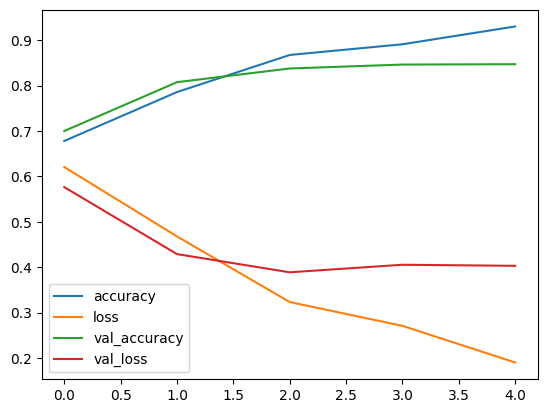

In [229]:
pd.DataFrame(history.history).plot()

**Зміна показників з навчанням, видно, що валідаційні втрати досягли плато але звичайні втрати зменшувались та точність росла**

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      2515
           1       0.87      0.84      0.85      2485

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



<Axes: >

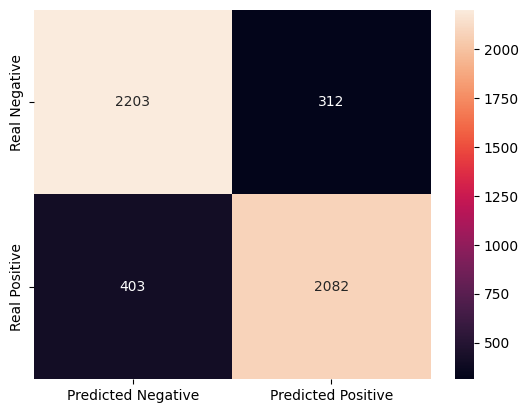

In [236]:
y_pred = np.round(model.predict(X_test)).astype(int)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='.0f', 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Real Negative', 'Real Positive'])

**Точність моделі доволі висока, але і неправильних визначень близько 15%**

In [231]:
embed_size = 64
model_v2 = keras.models.Sequential([
    keras.Input(shape=(None,)),
    keras.layers.Embedding(input_dim=10000, output_dim=embed_size, mask_zero=True),
    keras.layers.SpatialDropout1D(0.2),
    keras.layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(1, activation='sigmoid')
])
model_v2.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, None, 64)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ (None, None, 64)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

**Тепер натренуємо більш складну та часозатратну модель з дропаутами для уникнення перетренування, зробимо більше епох порівняно з минулою моделлю**

In [232]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model_v2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model_v2.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_valid, y_valid))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 232s 977ms/step - accuracy: 0.5317 - loss: 0.6925 - val_accuracy: 0.5762 - val_loss: 0.6851
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 232s 989ms/step - accuracy: 0.6761 - loss: 0.6505 - val_accuracy: 0.7942 - val_loss: 0.5402
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 231s 982ms/step - accuracy: 0.7653 - loss: 0.5733 - val_accuracy: 0.8256 - val_loss: 0.4748
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 231s 982ms/step - accuracy: 0.8042 - loss: 0.5249 - val_accuracy: 0.8378 - val_loss: 0.4354
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 230s 980ms/step - accuracy: 0.8249 - loss: 0.4947 - val_accuracy: 0.8506 - val_loss: 0.4153
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 231s 984ms/step - accuracy: 0.8350 - loss: 0.4752 - val_accuracy: 0.8580 - val_loss: 0.4143
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 230s 977ms/step - accuracy: 0.8523 - loss: 0.4361 - val_accuracy: 0.8466 - val_loss: 0.4057
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 230s 979ms/step - accuracy: 0.8496 -

<Axes: >

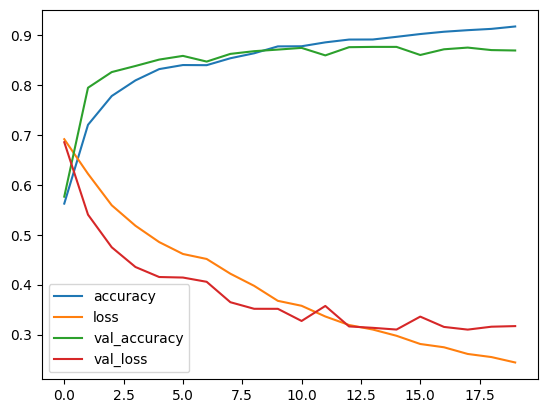

In [233]:
pd.DataFrame(history.history).plot()

**На відміну від минулою моделі тут loss-и спадають однаково та стабільно**

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2515
           1       0.86      0.88      0.87      2485

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



<Axes: >

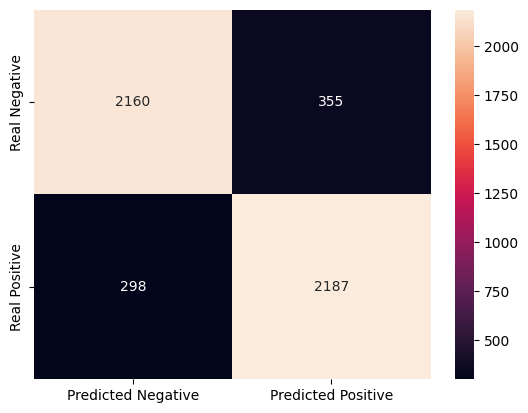

In [235]:
y_pred = np.round(model_v2.predict(X_test)).astype(int)


print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='.0f', 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Real Negative', 'Real Positive'])

**В цілому дана модель натренована краще, але різниця не велика**